# Inference Demo Notebook 

This notebook utilizes a Google Colab runtime (T4 GPU) for generation. If you aren't using Colab, skip this notebook and follow the README instructions under Quickstart.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HarshaSrirangam/stable-diffusion-rebuilt/blob/main/notebooks/inference_demo.ipynb)

## Environment/setup

In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device) # should be cuda

cuda


In [ ]:
# clone repo
!git clone https://github.com/HarshaSrirangam/stable-diffusion-rebuilt.git
%cd stable-diffusion-rebuilt
# !git pull

Cloning into 'stable-diffusion-rebuilt'...
remote: Enumerating objects: 545, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 545 (delta 28), reused 52 (delta 18), pack-reused 476 (from 1)
Receiving objects: 100% (545/545), 7.02 MiB | 4.98 MiB/s, done.
Resolving deltas: 100% (283/283), done.
/content/stable-diffusion-rebuilt


In [4]:
# the README uses uv sync for local generation. Because this is a Colab kernel,
# we instead install the package into the Colab runtime, skipping torch/numpy
# which are preinstalled to Colab.
%pip install -e . --no-deps -q
%pip install transformers safetensors tqdm accelerate pyyaml datasets -q
import sys
sys.path.insert(0, "/content/stable-diffusion-rebuilt/src")

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for stable-diffusion-rebuilt (pyproject.toml) ... done


In [32]:
# download LoRA weights and SD1.5 checkpoint from HuggingFace
!python scripts/download_data.py
!ls data/weights # should contain persian_lora.safetensors and v1-5-pruned-emaonly.safetensors


v1-5-pruned-emaonly.safetensors: downloading bytes:   0% 0.00/4.27G [00:00<?, ?B/s]s]
v1-5-pruned-emaonly.safetensors: downloading bytes:   5% 202M/4.27G [00:02<00:18, 223MB/s, 12.1MB/s  ]  
v1-5-pruned-emaonly.safetensors: downloading bytes:   6% 258M/4.27G [00:02<00:14, 284MB/s, 19.1MB/s  ]s  ]
v1-5-pruned-emaonly.safetensors: downloading bytes:  10% 437M/4.27G [00:02<00:08, 442MB/s, 33.4MB/s  ] ]  
v1-5-pruned-emaonly.safetensors: downloading bytes:  12% 523M/4.27G [00:02<00:07, 532MB/s, 40.4MB/s  ] ]
v1-5-pruned-emaonly.safetensors: downloading bytes:  20% 847M/4.27G [00:03<00:06, 546MB/s, 70.0MB/s  ] ]
v1-5-pruned-emaonly.safetensors: downloading bytes:  21% 909M/4.27G [00:03<00:05, 562MB/s, 75.1MB/s  ] ]
v1-5-pruned-emaonly.safetensors: downloading bytes:  23% 970M/4.27G [00:03<00:05, 575MB/s, 80.1MB/s  ] ]
v1-5-pruned-emaonly.safetensors: downloading bytes:  24% 1.03G/4.27G [00:03<00:05, 585MB/s, 85.0MB/s  ]]
v1-5-pruned-emaonly.safetensors: downloading bytes:  27% 1.16G/4.27G 

# Inference

### Method 1: config/script-driven (fast and easy)

In [ ]:
%%writefile configs/inference.yaml
# LoRA inference
prompt: "a bird perched on a blossoming branch"
negative_prompt: "photograph, photorealistic, 3d render, blurry, low quality, modern"
seed: 1
input_image: null
strength: 0.8
lora_path: data/weights/persian_lora.safetensors
pretrained_path: data/weights/v1-5-pruned-emaonly.safetensors
device: cuda
sampler: ddim
n_steps: 50
guidance_scale: 7.5

Overwriting configs/inference.yaml


In [70]:
!python scripts/generate.py


>>> Loading base model

>>> Loading LoRA adapter

>>> Generating image
Denoising: 100% 50/50 [00:04<00:00, 11.23it/s]

>>> Saving output

>>> Saved to /content/stable-diffusion-rebuilt/outputs/out1


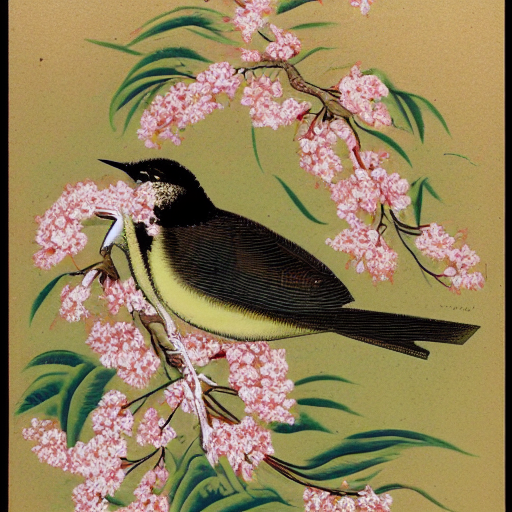

In [71]:
from pathlib import Path
from IPython.display import Image, display

# display generated image
latest = max(Path("outputs").glob("out*"), key=lambda p: int(p.name[3:]))
display(Image(filename=latest / "output.png"))

In [ ]:
%%writefile configs/inference.yaml
# base model inference
prompt: "a bird perched on a blossoming branch"
negative_prompt: "photograph, photorealistic, 3d render, blurry, low quality, modern"
seed: 1
input_image: null
strength: 0.8
lora_path: null
pretrained_path: data/weights/v1-5-pruned-emaonly.safetensors
device: cuda
sampler: ddim
n_steps: 50
guidance_scale: 7.5

Overwriting configs/inference.yaml


In [73]:
!python scripts/generate.py


>>> Loading base model

>>> Generating image
Denoising: 100% 50/50 [00:03<00:00, 12.63it/s]

>>> Saving output

>>> Saved to /content/stable-diffusion-rebuilt/outputs/out2


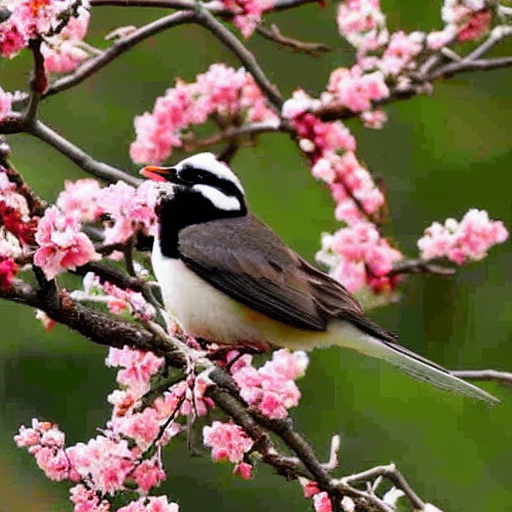

In [74]:
# display generated image
latest = max(Path("outputs").glob("out*"), key=lambda p: int(p.name[3:]))
display(Image(filename=latest / "output.png"))

### Method 2: call pipeline directly (full control)

Denoising: 100%|██████████| 50/50 [00:03<00:00, 13.65it/s]


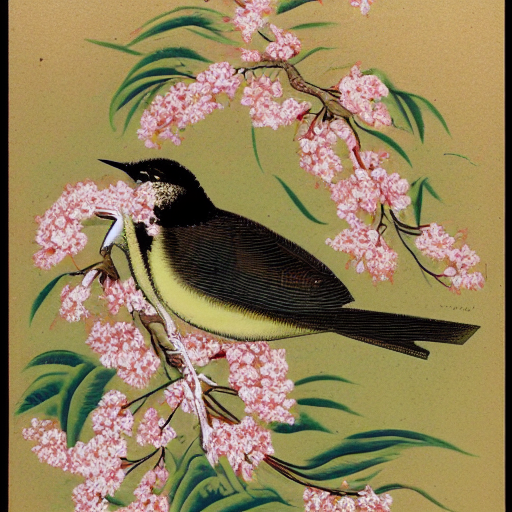

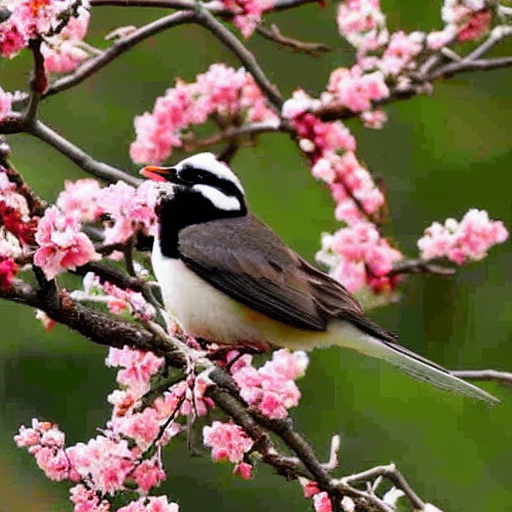

In [76]:
from transformers import CLIPTokenizer
from stablediffusion.autoencoder import Autoencoder
from stablediffusion.clip import CLIP
from stablediffusion.unet import UNet
from convert_weights import load_all
from samplers.ddim import DDIM
from safetensors.torch import load_file, safe_open
from lora.utils import inject_lora, disable_lora, enable_lora
from inference import InferencePipeline
from PIL import Image as PILImage

# initialize model, tokenizer, and sampler
vae, clip, unet = Autoencoder().eval(), CLIP().eval(), UNet().eval()
load_all("data/weights/v1-5-pruned-emaonly.safetensors", vae, clip, unet)
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
sampler = DDIM() # n_step = 50 by default

# inject LoRA layers
lora_path = "data/weights/persian_lora.safetensors"
lora_state = load_file(lora_path)
with safe_open(lora_path, framework="pt") as f:
    meta = f.metadata()
inject_lora(
    model=unet,
    target_names=meta["targets"].split(","),
    r=int(meta["r"]),
    alpha=int(meta["alpha"]),
)
_ = unet.load_state_dict(lora_state, strict=False)

# pipeline
pipeline = InferencePipeline(
    vae=vae,
    clip=clip,
    unet=unet,
    sampler=sampler,
    tokenizer=tokenizer,
    device=device,
    idle_device="cpu"
)

# generate images (LoRA and base model)
prompt = "a bird perched on a blossoming branch"
negative_prompt = "photograph, photorealistic, 3d render, blurry, low quality, modern"
seed = 1

enable_lora(unet)
lora_out = pipeline.txt_2_img(prompt=prompt, negative_prompt=negative_prompt, seed=seed)
disable_lora(unet)
base_out = pipeline.txt_2_img(prompt=prompt, negative_prompt=negative_prompt, seed=seed)

# display generated images
display(PILImage.fromarray(lora_out))
display(PILImage.fromarray(base_out))
